<a href="https://colab.research.google.com/github/OlgaGarkavenko/irish-DS-ML/blob/main/hw01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import confusion_matrix, adjusted_rand_score, classification_report

# task1
# Завантаження датасету Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
# Додаємо текстові назви класів для зручності візуалізації
species_map = {0: "setosa", 1: "versicolor", 2: "virginica"}
df["species"] = df["target"].map(species_map)

print("Перші 5 рядків DataFrame:")
print(df.head())
print(f"\nРозмір датасету: {df.shape[0]} рядків × {df.shape[1]} стовпців")

Перші 5 рядків DataFrame:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Розмір датасету: 150 рядків × 6 стовпців


In [30]:
# task 2
print('Статистичні характеристики (describe):')
print(df.describe().round(2))

print('Статистика по кожному виду:')
print(df.groupby('species')[iris.feature_names].mean().round(2))

Статистичні характеристики (describe):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            150.00  150.00  
mean               1.20    1.00  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  
Статистика по кожному виду:
            sepal length (cm)  sepal widt

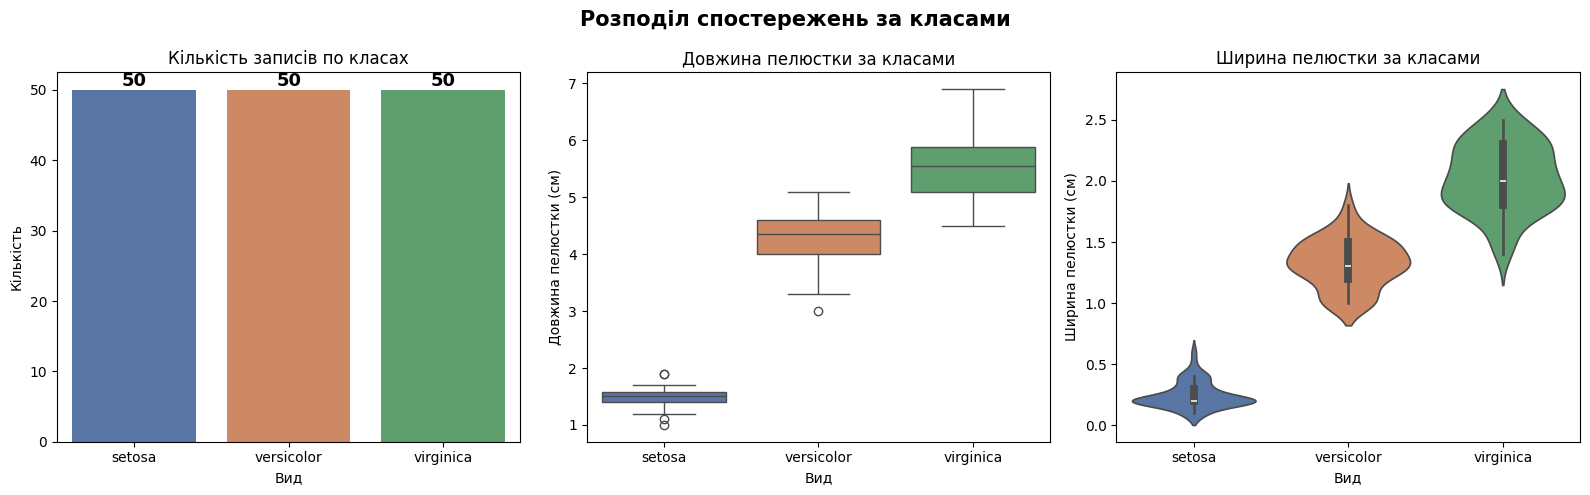

Графік збережено.


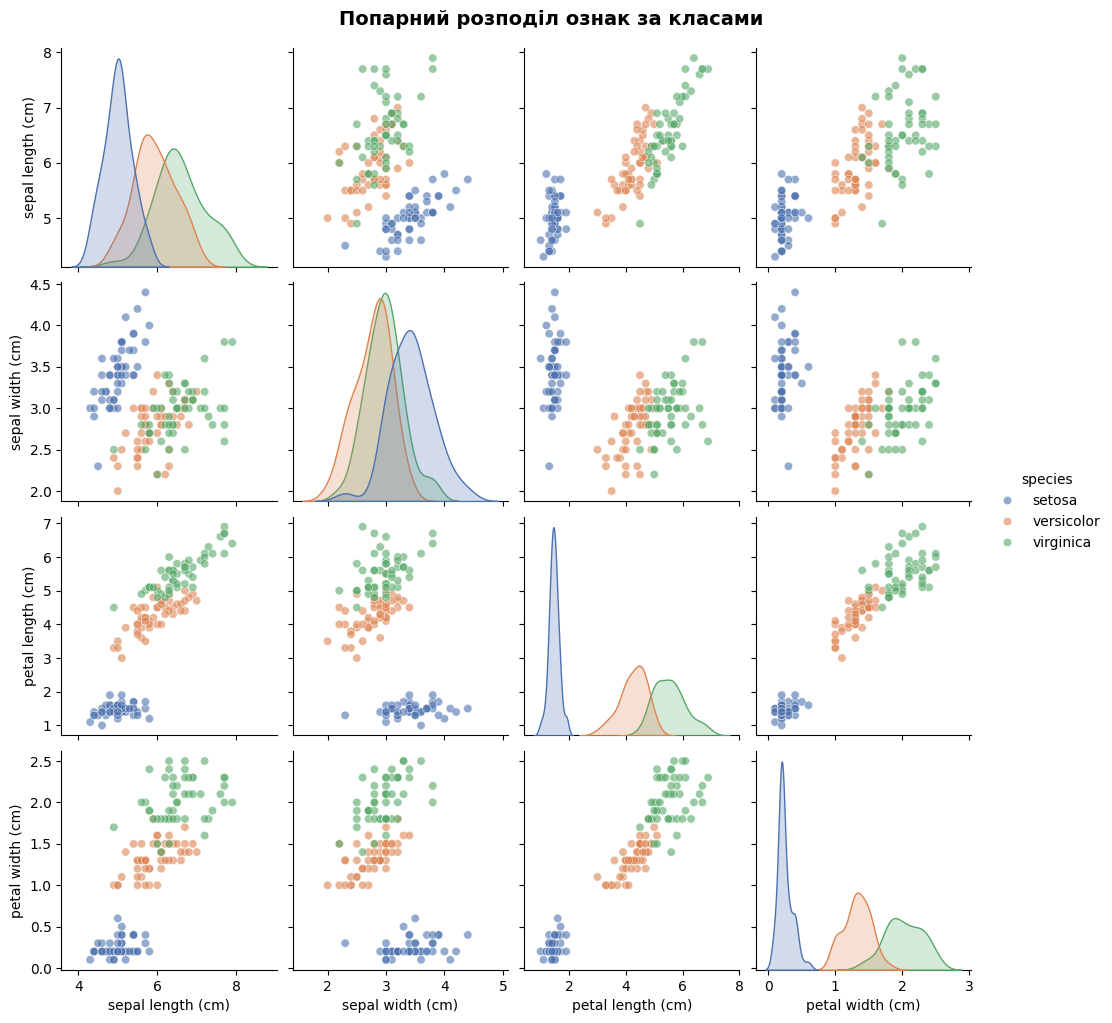

Pairplot збережено.


In [31]:
# task 3

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Розподіл спостережень за класами', fontsize=15, fontweight='bold')

palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

# 1) Кількість записів по класах
sns.countplot(data=df, x='species', hue='species', palette=palette, legend=False, ax=axes[0])
axes[0].set_title('Кількість записів по класах')
axes[0].set_xlabel('Вид')
axes[0].set_ylabel('Кількість')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

# 2) Boxplot: довжина пелюстки
sns.boxplot(data=df, x='species', y='petal length (cm)', hue='species', palette=palette, legend=False, ax=axes[1])
axes[1].set_title('Довжина пелюстки за класами')
axes[1].set_xlabel('Вид')
axes[1].set_ylabel('Довжина пелюстки (см)')

# 3) Violinplot: ширина пелюстки
sns.violinplot(data=df, x='species', y='petal width (cm)', hue='species', palette=palette, legend=False, ax=axes[2])
axes[2].set_title('Ширина пелюстки за класами')
axes[2].set_xlabel('Вид')
axes[2].set_ylabel('Ширина пелюстки (см)')

plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')  # збереження в поточну папку
plt.show()
print('Графік збережено.')


# Pairplot — попарний розподіл ознак
g = sns.pairplot(df, hue='species', palette=palette,
                 vars=iris.feature_names, plot_kws={'alpha': 0.6})
g.figure.suptitle('Попарний розподіл ознак за класами', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('plot_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pairplot збережено.')

In [28]:
# task 4
iris = load_iris()

features = iris.feature_names
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nСередні значення після стандартизації:")
print(pd.DataFrame(X_scaled, columns=features).mean())

print("\nСтандартні відхилення після стандартизації:")
print(pd.DataFrame(X_scaled, columns=features).std())


Середні значення після стандартизації:
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

Стандартні відхилення після стандартизації:
sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64


In [12]:
# task 5
spectral = SpectralClustering(
    n_clusters=3, affinity="nearest_neighbors", random_state=42
)
clusters = spectral.fit_predict(X_scaled)
df["cluster"] = clusters

In [27]:
# task 6
spectral = SpectralClustering(
    n_clusters=3, affinity="nearest_neighbors", random_state=42
)

# Отримуємо номери кластерів і записуємо їх у DataFrame
df["cluster"] = spectral.fit_predict(X_scaled)

cm = confusion_matrix(df["target"], df["cluster"])
print("\nМатриця невідповідностей:")
print(cm)


Матриця невідповідностей:
[[ 0 49  1]
 [ 3  0 47]
 [32  0 18]]


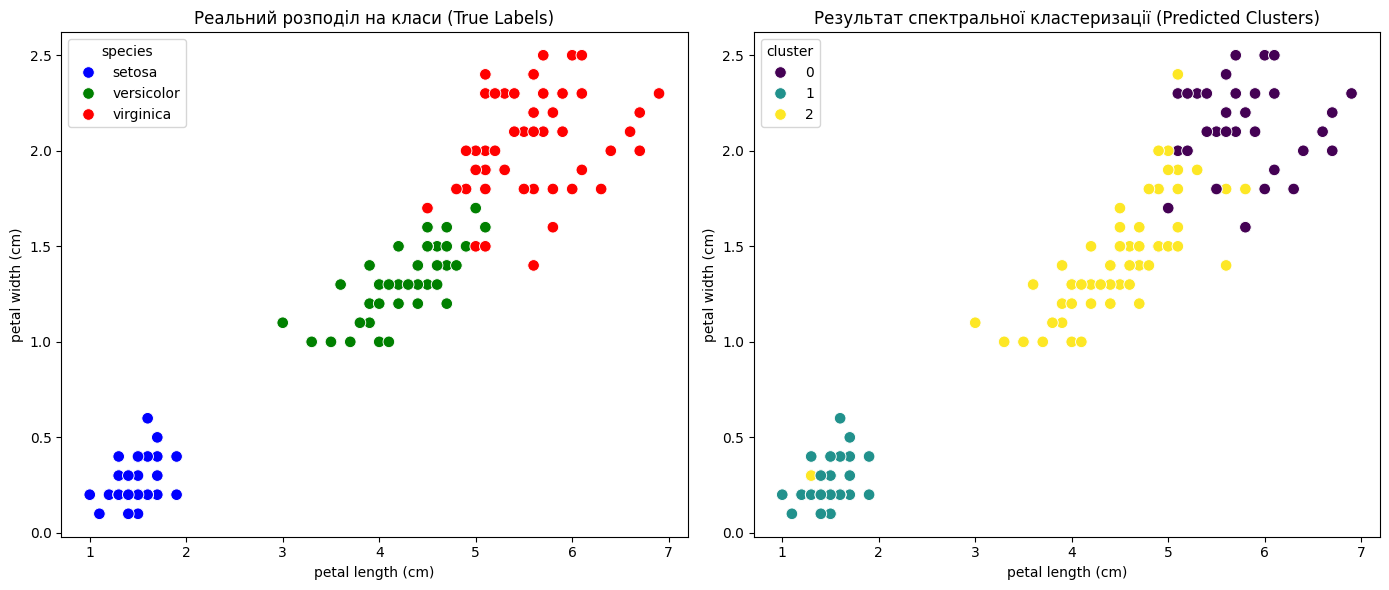

In [25]:
# task 7
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
palette = {
    "setosa": "blue",
    "versicolor": "green",
    "virginica": "red"
}
# Графік реальних класів
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette=palette,
    ax=ax1,
    s=70,
)
ax1.set_title("Реальний розподіл на класи (True Labels)")

# Графік знайдених кластерів
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="cluster",
    palette="viridis",
    ax=ax2,
    s=70,
)
ax2.set_title("Результат спектральної кластеризації (Predicted Clusters)")

plt.tight_layout()
plt.show()

Виконавши спектральну кластеризацію для датасету Ірисів Фішера, я зробив кілька цікавих спостережень:

1. Дані та їх підготовка.
Датасет дуже зручний, бо всі три класи (setosa, versicolor, virginica) мають однакову кількість записів — рівно по 50. Перед початком роботи я обов'язково зробив стандартизацію через StandardScaler. Без цього ознаки з більшими числами (як-от довжина чашолистка) просто «задавили» б інші параметри під час розрахунків.

2. Як впорався алгоритм.
Спектральна кластеризація показала крутий результат. Клас setosa алгоритм відпрацював ідеально (50 з 50), бо він навіть на графіках візуально стоїть окремо від інших. З versicolor та virginica виникли невеликі труднощі — кілька квіток переплуталися. Але це абсолютно нормально, оскільки в реальному житті їхні розміри пелюсток сильно накладаються один на одного.

3. Підсумок.
Матриця невідповідностей та фінальні графіки чітко доводять: навіть без підказок (тобто без використання готових міток target), алгоритм зміг самостійно розділити квіти на три групи, які майже на 95% збігаються з реальною біологічною класифікацією. Метод дійсно робочий для пошуку прихованих закономірностей у даних.